# Visualization

Companion notebook for the [Visualization](https://ddacs.readthedocs.io/en/latest/tutorials/visualization/) tutorial. It is written to stand on its own: every step is annotated so the notebook reads top to bottom.

## Walkthrough

1. open one HDF5 simulation file with `ddacs.open_h5`,
2. render the formed blank as a mesh coloured by sheet thickness,
3. plot the four OP10 components as a point cloud in a single axis,
4. compute the cutting-induced springback magnitude on the OP20 blank,
5. render the springback as a vector field with arrow glyphs.

## Assumptions

- This notebook lives in `notebooks/` of the repository. The data directory `./data` therefore resolves to `../data` from here.
- `ddacs download --small` has been run once from the repository root, so `../data/` contains `metadata.json`, `process_parameters.csv`, and the bundled sample zip.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import ddacs
from ddacs.visualization import FALSE_COLOR_CMAP, COMPONENT_COLORS

print('ddacs', ddacs.__version__)

from pathlib import Path
DATA_DIR = Path('../data')
sim_id   = 258864

# colormap for springback
ROCKET = sns.color_palette('rocket', as_cmap=True)

ddacs 3.1.3


## 1. Thickness mesh

The blank ships with both initial coordinates (`node_coordinates`) and per-timestep positions (`node_displacement[t]`). Plotting the formed state means using `node_displacement[-1]` together with `element_shell_thickness[-1]` so geometry and colour map come from the same timestep.

Three choices drive the plot:

- `FALSE_COLOR_CMAP` : diverging red->green->blue. With `vmin = nominal - delta`, `vmax = nominal + delta`, green falls on the nominal sheet thickness, so deviations read as thinning (red) or thickening (blue).
- `mirror=True` : the simulation models a quarter of the cup by symmetry; mirroring across `x = 0` and `y = 0` reconstructs the full part.
- ISO 80000-2 axis labels : variables italic, units upright. Applied automatically.

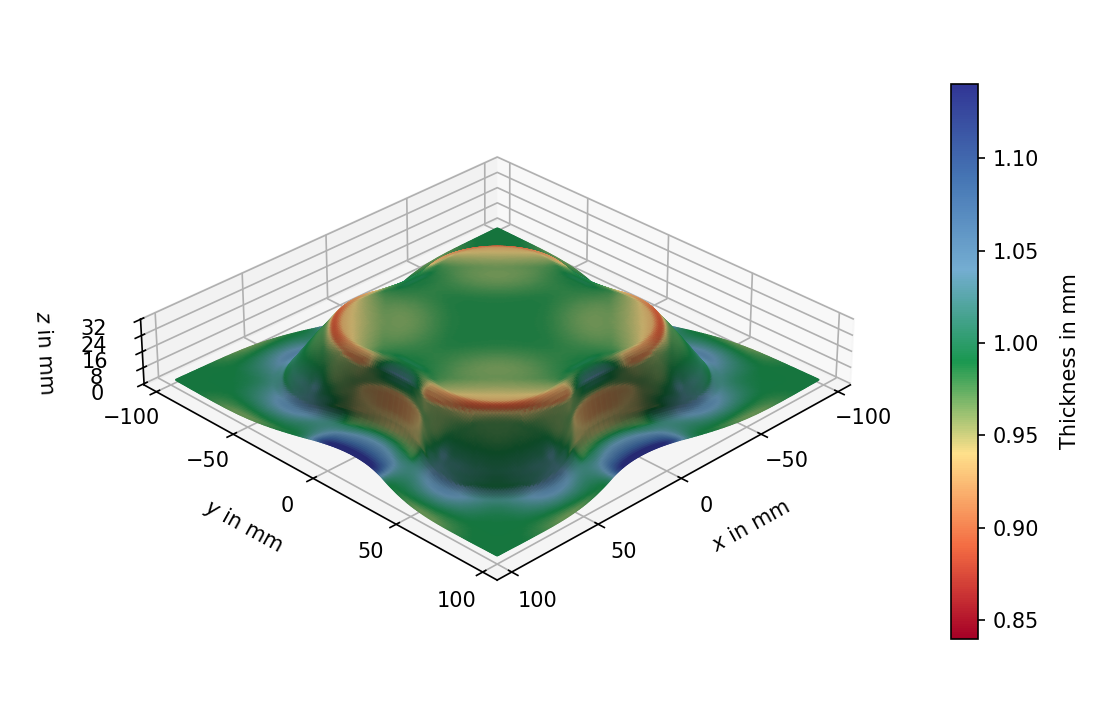

In [2]:
with ddacs.open_h5(sim_id, data_dir=DATA_DIR) as f:
    nodes     = f['OP10/blank/node_displacement'][-1]
    faces     = f['OP10/blank/element_shell_node_indexes'][:]
    thickness = f['OP10/blank/element_shell_thickness'][-1]
    nominal   = float(f.attrs['sheet_metal_thickness'])

half_range = 0.15
ax, cbar = ddacs.plot_mesh(
    nodes, faces,
    values=thickness,
    cmap=FALSE_COLOR_CMAP,
    vmin=nominal - half_range,
    vmax=nominal + half_range,
    colorbar_label='Thickness in mm',
    mirror=True,
)
plt.show()

## 2. Component meshes in a 2 x 2 grid

OP10 stores positions and shell connectivity for all four components. The face indices in `element_shell_node_indexes` are **global** : they index into the concatenation of all components' nodes : so each component's own slice starts at an offset. Subtracting `face_idx.min()` per component recovers valid local indices into the component's `node_displacement` array.

Three knobs drive the frame:

- `MIRROR` : when `True`, each subplot uses `xlim/ylim = (-xmax, xmax) / (-ymax, ymax)`; when `False`, the data stays in one quadrant so the limits start at `0`.
- `PAD_XY = 1.15` : the die and binder are a few mm wider than the blank in xy, so the blank-derived limits are padded outward by 15 % to keep them inside the frame.
- `set_box_aspect((dx, dy, dz))` : using data spans (not `(1, 1, 1)`) preserves the honest cup-vs-tool proportions; the binder is correctly flat at `z = 0`.

The three tools are rendered with a black wireframe to make the mesh density visible; the blank stays mono-coloured since the smooth shading reads cleaner against the workpiece colour.

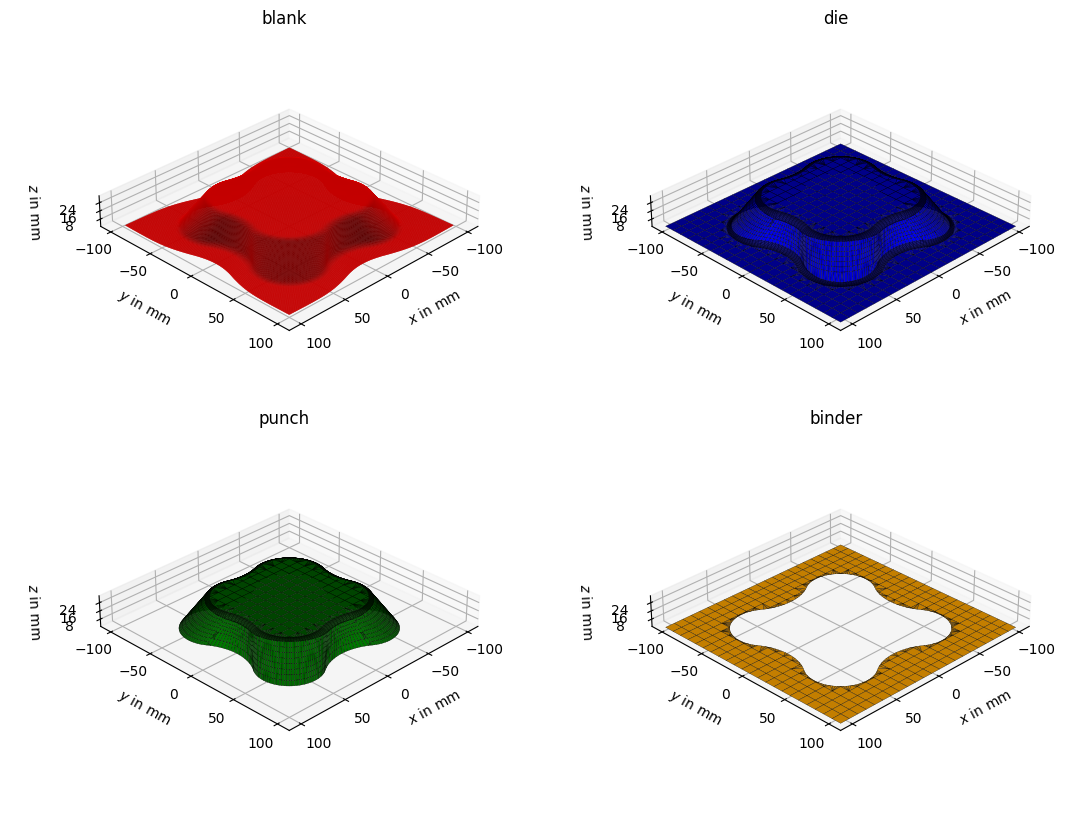

In [3]:
with ddacs.open_h5(sim_id, data_dir=DATA_DIR) as f:
    parts = {
        name: (
            f[f'OP10/{name}/node_displacement'][-1],
            f[f'OP10/{name}/element_shell_node_indexes'][:],
        )
        for name in COMPONENT_COLORS
    }

MIRROR = True 
PAD_XY = 1.15

# Derive the frame from the blank : it has the full xyz extent and sits on the symmetry axes.
# The die and binder are a few mm wider than the blank in xy, so pad outward.
blank_nodes = parts['blank'][0]
zmin = float(blank_nodes[:, 2].min())
zmax = float(blank_nodes[:, 2].max())
if MIRROR:
    xmax = float(np.abs(blank_nodes[:, 0]).max()) * PAD_XY
    ymax = float(np.abs(blank_nodes[:, 1]).max()) * PAD_XY
    xlim = (-xmax, xmax)
    ylim = (-ymax, ymax)
else:
    xlim = (0, float(blank_nodes[:, 0].max()) * PAD_XY)
    ylim = (0, float(blank_nodes[:, 1].max()) * PAD_XY)

zlim = (zmin, zmax)
box_aspect = (xlim[1] - xlim[0], ylim[1] - ylim[0], zmax - zmin)

fig, axes = plt.subplots(
    2, 2,
    figsize=(11, 8),
    subplot_kw={'projection': '3d'},
    constrained_layout=True,
)

for ax, name in zip(axes.flat, COMPONENT_COLORS):
    nodes, faces = parts[name]
    faces = faces - faces.min()        # global -> local indices
    edgecolor = COMPONENT_COLORS[name] if name == 'blank' else 'black'
    ddacs.plot_mesh(
        nodes, faces,
        ax=ax,
        facecolors=COMPONENT_COLORS[name],
        edgecolors=edgecolor,
        linewidth=0.2,
        mirror=MIRROR,
    )
    ax.set_title(name)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_zlim(zlim)
    ax.set_box_aspect(box_aspect)

# Reserve a tiny left margin so the z-axis labels of the two left subplots are not clipped.
fig.text(0.0, 0.0, " ")
plt.show()

## 3. Springback magnitude

**Springback** is the elastic recovery of the workpiece after the tools release. Once the load is removed, the part partially snaps back towards its original geometry and a residual displacement field remains. It is the dominant geometric error in stamping and the standard target for ML models trained on this dataset.

OP20 stores two blank timesteps: the state immediately after cutting (still under contact) and the relaxed state after springback. The per-node delta `pos[-1] - pos[-2]` is the springback vector; its magnitude `|delta|` is the standard scalar field for "how much did this node move?". Plotting it on the OP20 mesh (rocket cmap from seaborn: dark purple, orange, pale yellow) shows where the part deforms most strongly on the actual surface.

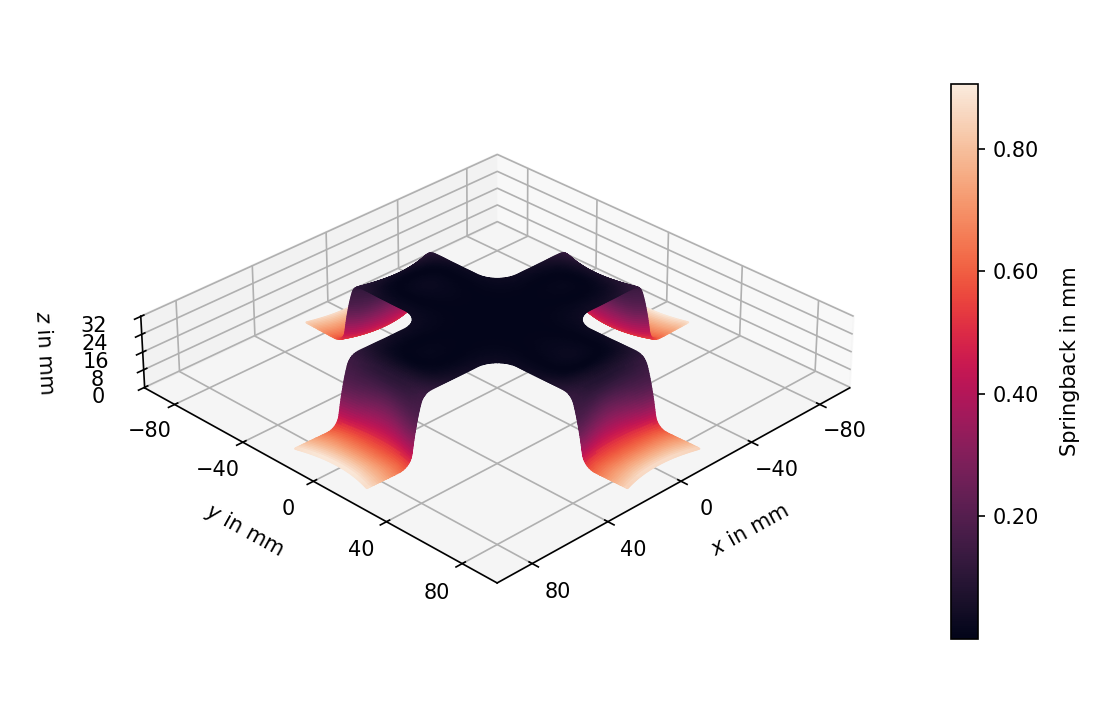

In [4]:
with ddacs.open_h5(sim_id, data_dir=DATA_DIR) as f:
    pos     = f['OP20/blank/node_displacement'][:]
    faces20 = f['OP20/blank/element_shell_node_indexes'][:]

displacement   = pos[-1] - pos[-2]
magnitude      = np.linalg.norm(displacement, axis=1)
# plot_mesh expects per-face values; average the per-node magnitude over each face.
face_magnitude = magnitude[faces20.astype(np.int64)].mean(axis=1)

ax, cbar = ddacs.plot_mesh(
    pos[-1], faces20,
    values=face_magnitude,
    cmap=ROCKET,
    vmin=float(magnitude.min()),
    vmax=float(magnitude.max()),
    colorbar_label='Springback in mm',
    mirror=True,
    shade=False
)
plt.show()

## 4. Springback vector field

Magnitude alone hides direction: a node that springs radially inward looks the same as one that drops vertically. `plot_vectors` renders the per-node delta as arrows, so both the local magnitude (arrow colour) and the local direction (arrow vector) are visible.

`plot_vectors` is a pure arrow renderer. It does not draw an underlying point cloud or mesh. Passing `values=magnitude` colours each arrow by the springback and builds a matching colorbar. `step` thins the arrow density so the field stays readable. The default rendering draws a thin black outline behind each arrow (configurable via `outline_kwargs`, suppress with `outline_kwargs={'linewidth': 0}`).

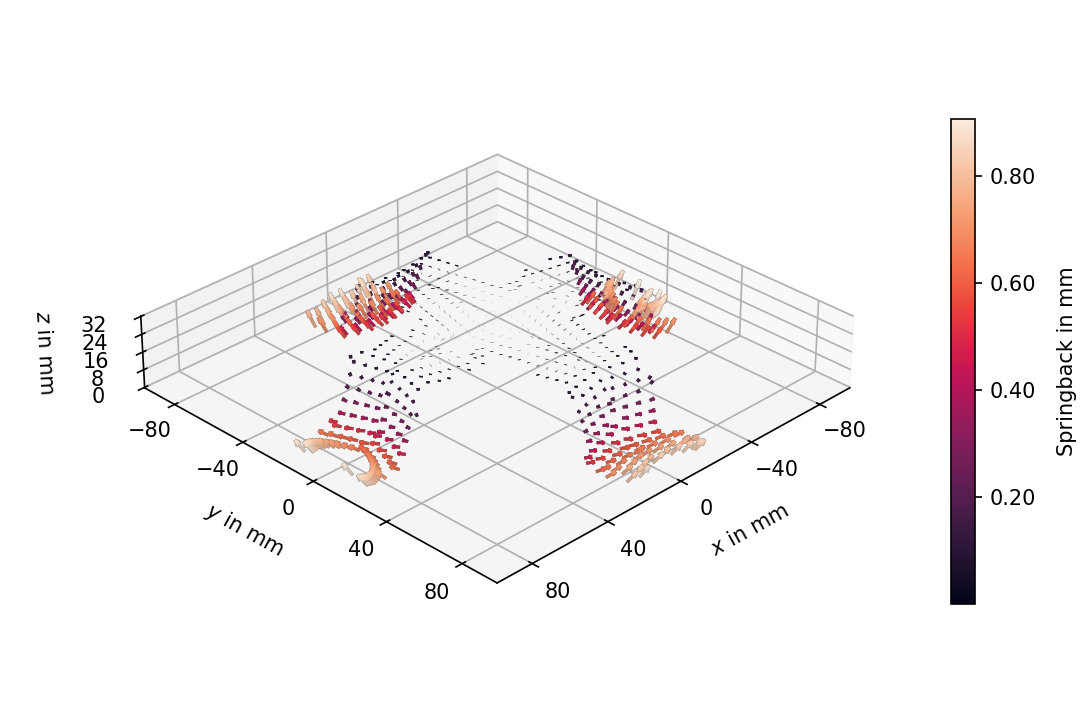

In [5]:
ax, cbar = ddacs.plot_vectors(
    pos[-1],
    displacement,
    values=magnitude,
    step=25,
    scale=10.0,
    cmap=ROCKET,
    colorbar_label='Springback in mm',
    mirror=True,
)
plt.show()

## 5. Compose: arrows on a coloured mesh

Sections 3 and 4 each show one aspect of the springback: magnitude on a mesh (Section 3) or magnitude plus direction on arrows (Section 4). They can be combined on the same axis to convey both at once. The mesh carries the magnitude (rocket cmap); the arrows carry the direction.

Because `plot_mesh`, `plot_point_cloud`, and `plot_vectors` all accept an existing `ax`, composition is just two calls in sequence. Solid red arrows are chosen on top so they read as overlay glyphs and do not duplicate the rocket signal already on the mesh.

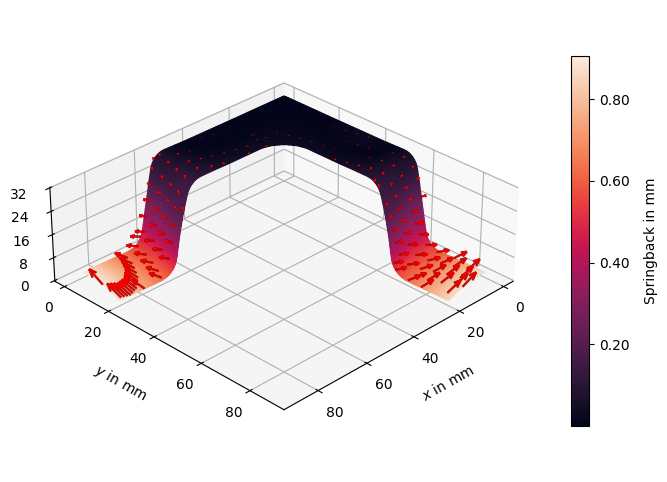

In [6]:
fig = plt.figure(figsize=(8, 6))
ax  = fig.add_subplot(111, projection='3d')

ddacs.plot_mesh(
    pos[-1], faces20,
    values=face_magnitude,
    ax=ax,
    cmap=ROCKET,
    vmin=float(magnitude.min()),
    vmax=float(magnitude.max()),
    colorbar_label='Springback in mm',
    mirror=False,
    shade=False
)
# Mesh already encodes magnitude. Arrows in solid red just convey direction.
ddacs.plot_vectors(
    pos[-1],
    displacement,
    ax=ax,
    step=25,
    scale=10.0,
    arrow_kwargs={'color': 'red'},
    mirror=False,
)
plt.show()